# Exact reproduction of the selected band subspace on the wannierization mesh

With `cutoff=0` every real-space hopping generated by the Fourier transform of the converged
Bloch gauge is kept (nothing truncated), so the reconstruction $H_{\rm wan}(k)=\sum_R h_R\,
e^{i2\pi k\cdot R}$ is an *exact* Fourier interpolation, not an approximation: at every k-point
of the wannierization mesh, the eigenvalues of $H_{\rm wan}(k)$ must reproduce the selected
eigenvalues of the original $H(k)$ to numerical precision. This holds for a full band manifold
(`bands=[0,num_bands-1]`, always exact regardless of the mesh) and, for the symmetric ladder
below, even for a single isolated band -- its lowest band is an exact, k-independent bonding
combination, a genuine zero-spread case. The default `cutoff` (`1e-6`) instead truncates
negligible long-range hoppings for a more compact model, trading exact mesh reproduction for a
small, bounded interpolation error.

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

Total spread Omega (exact reconstruction, should be ~0): 6.835738294938642e-13
Max eigenvalue difference over the mesh: 8.881784197001252e-16


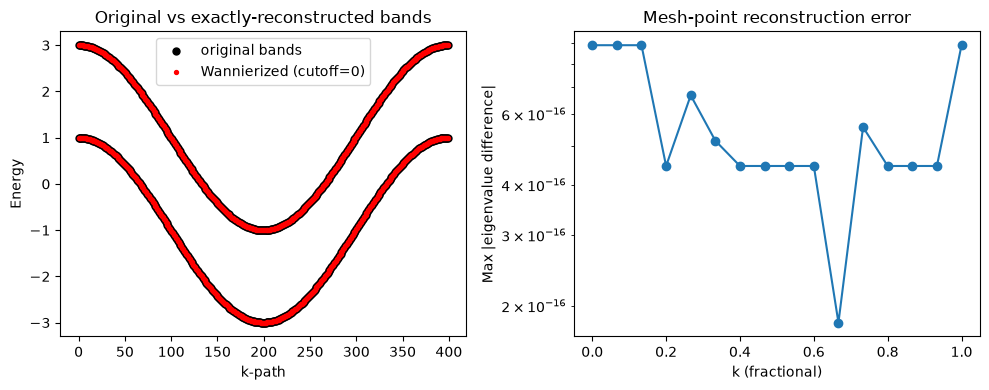

In [2]:
g = geometry.ladder()
h = g.get_hamiltonian(has_spin=False)

# full 2-band manifold, cutoff=0: no truncation, provably exact regardless of geometry
h_full = h.get_wannier_hamiltonian(bands=[0,1],nk=16,cutoff=0.0)

hk_gen  = h.get_hk_gen()
hk_gen1 = h_full.get_hk_gen()
ks = np.linspace(0.,1.,16)
maxerr = 0.0
diffs = []
for kx in ks:
    k3 = np.array([kx,0.,0.])
    e_ref  = np.sort(np.linalg.eigvalsh(hk_gen(k3)))
    e_wan  = np.sort(np.linalg.eigvalsh(hk_gen1(k3)))
    d = np.max(np.abs(e_wan-e_ref))
    diffs.append(d)
    maxerr = max(maxerr,d)

print("Total spread Omega (exact reconstruction, should be ~0):",h_full.wannier_spread_total)
print("Max eigenvalue difference over the mesh:",maxerr)

(k,e) = h.get_bands(write=False)
(kw,ew) = h_full.get_bands(write=False)

fig,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].scatter(k,e,c="black",s=25,label="original bands")
axs[0].scatter(kw,ew,c="red",s=8,label="Wannierized (cutoff=0)")
axs[0].set_xlabel("k-path") ; axs[0].set_ylabel("Energy") ; axs[0].legend()
axs[0].set_title("Original vs exactly-reconstructed bands")
axs[1].semilogy(ks,np.array(diffs)+1e-18,marker="o")
axs[1].set_xlabel("k (fractional)") ; axs[1].set_ylabel("Max |eigenvalue difference|")
axs[1].set_title("Mesh-point reconstruction error")
plt.tight_layout()
plt.show()